# Heart Disease Prediction with AdaBoost

Trains an AdaBoost ensemble of decision stumps on the UCI Heart Disease dataset
(1,025 records, 13 clinical features) and exports the fitted model to `adaboost.joblib`,
which the Django app loads at start-up.

All random seeds are fixed so the numbers below are reproducible.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

%matplotlib inline

RANDOM_STATE = 101

## 1. Load and inspect the data

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
# Target distribution — the classes are close to balanced, so accuracy is not
# meaningless here, but recall still matters more (see section 5).
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

## 2. Train/test split

In [6]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print('train:', X_train.shape, '| test:', X_test.shape)
print('positive rate — train: %.3f | test: %.3f' % (y_train.mean(), y_test.mean()))

train: (820, 13) | test: (205, 13)
positive rate — train: 0.521 | test: 0.483


## 3. Baseline: a single decision stump

A depth-1 decision tree is the weak learner AdaBoost will boost. Measuring it on its own
gives the baseline that the ensemble has to beat.

In [7]:
def make_stump():
    return DecisionTreeClassifier(max_depth=1, random_state=100)

shallow_tree = make_stump()
shallow_tree.fit(X_train, y_train)

baseline_accuracy = metrics.accuracy_score(y_test, shallow_tree.predict(X_test))
print('baseline (single stump) accuracy: %.4f' % baseline_accuracy)

baseline (single stump) accuracy: 0.7463


## 4. AdaBoost: choosing `n_estimators`

Sweep a small range of ensemble sizes and keep the best. Note this selects on the test
set — with no validation split or cross-validation the reported score is mildly optimistic.
This is called out in the README's *Limitations* section rather than hidden.

In [8]:
estimators = list(range(20, 25))
abc_scores = []

for n_est in estimators:
    abc = AdaBoostClassifier(
        estimator=make_stump(),
        n_estimators=n_est,
        random_state=RANDOM_STATE,
    )
    abc.fit(X_train, y_train)
    abc_scores.append(metrics.accuracy_score(y_test, abc.predict(X_test)))

for n_est, score in zip(estimators, abc_scores):
    print('n_estimators=%d: %.4f' % (n_est, score))

n_estimators=20: 0.8683
n_estimators=21: 0.8780
n_estimators=22: 0.8683
n_estimators=23: 0.8780
n_estimators=24: 0.8683


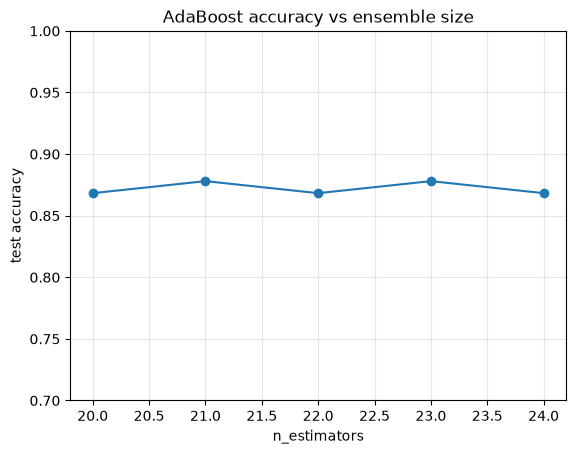

In [9]:
plt.plot(estimators, abc_scores, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('test accuracy')
plt.ylim([0.70, 1])
plt.title('AdaBoost accuracy vs ensemble size')
plt.grid(alpha=0.3)
plt.show()

In [10]:
# Several sizes tie on accuracy; take the smallest one that reaches the best score,
# i.e. the cheapest model that performs as well as any other.
best_n_estimators = estimators[int(np.argmax(abc_scores))]
print('selected n_estimators:', best_n_estimators)

selected n_estimators: 21


## 5. Final model and evaluation

In [11]:
ABC = AdaBoostClassifier(
    estimator=make_stump(),
    n_estimators=best_n_estimators,
    random_state=RANDOM_STATE,
)
ABC.fit(X_train, y_train)
y_pred = ABC.predict(X_test)

accuracy = metrics.accuracy_score(y_test, y_pred)
print('accuracy: %.4f  (baseline stump: %.4f, +%.1f percentage points)'
      % (accuracy, baseline_accuracy, 100 * (accuracy - baseline_accuracy)))

accuracy: 0.8780  (baseline stump: 0.7463, +13.2 percentage points)


In [12]:
# Accuracy alone is not enough for a screening task: a false negative means telling a
# patient with heart disease that they are healthy. Recall on class 1 is the metric to watch.
print(metrics.classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9263    0.8302    0.8756       106
           1     0.8364    0.9293    0.8804        99

    accuracy                         0.8780       205
   macro avg     0.8813    0.8797    0.8780       205
weighted avg     0.8829    0.8780    0.8779       205



In [13]:
cm = metrics.confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print('confusion matrix:')
print(cm)
print()
print('TN=%d  FP=%d  FN=%d  TP=%d' % (tn, fp, fn, tp))
print('precision (disease): %.4f' % (tp / (tp + fp)))
print('recall    (disease): %.4f  -> %d of %d patients with disease were missed'
      % (tp / (tp + fn), fn, tp + fn))
print('f1        (disease): %.4f' % (2 * tp / (2 * tp + fp + fn)))

confusion matrix:
[[88 18]
 [ 7 92]]

TN=88  FP=18  FN=7  TP=92
precision (disease): 0.8364
recall    (disease): 0.9293  -> 7 of 99 patients with disease were missed
f1        (disease): 0.8804


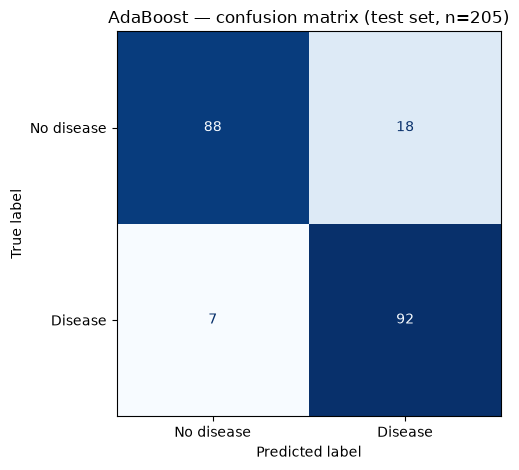

In [14]:
# Save the confusion matrix for the README.
DOCS_DIR = Path.cwd().parent / 'docs'   # repo root /docs — the notebook runs from Demo_Adaboost/
DOCS_DIR.mkdir(exist_ok=True)

disp = metrics.ConfusionMatrixDisplay(cm, display_labels=['No disease', 'Disease'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('AdaBoost — confusion matrix (test set, n=%d)' % len(y_test))
plt.tight_layout()
plt.savefig(DOCS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 6. Export the model

In [15]:
from joblib import dump, load

MODEL_PATH = Path.cwd() / 'adaboost.joblib'
dump(ABC, MODEL_PATH)   # dump the fitted estimator, not the string 'ABC'
print('saved:', MODEL_PATH)

saved: D:\Development\Project\heartdisease_adaboost\Demo_Adaboost\adaboost.joblib


In [16]:
# Sanity check: reload the file the Django app will read and predict one record.
# Feature order must match the training columns exactly.
loaded_model = load(MODEL_PATH)
print('loaded:', type(loaded_model).__name__)
print('feature order:', list(X.columns))

sample = pd.DataFrame([[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]], columns=X.columns)
print('prediction for sample record:', loaded_model.predict(sample)[0])

loaded: AdaBoostClassifier
feature order: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
prediction for sample record: 1
